In [1]:
# 1: Imports & basic setup

import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# 2: Mount Google Drive & define paths

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = PROJECT_ROOT / "data"
RAW_FILE = DATA_DIR / "raw" / "pretrain" / "spotify_tracks.csv"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SONG_DATASET_CLEAN = PROCESSED_DIR / "song_dataset_clean.csv"
SONG_SCALER_FILE = PROCESSED_DIR / "song_scaler.pkl"
SONG_EMBEDDINGS_FILE = PROCESSED_DIR / "song_embeddings.npy"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_FILE:", RAW_FILE)
print("PROCESSED_DIR:", PROCESSED_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/mbti-tune
RAW_FILE: /content/drive/MyDrive/mbti-tune/data/raw/pretrain/spotify_tracks.csv
PROCESSED_DIR: /content/drive/MyDrive/mbti-tune/data/processed


In [3]:
# 3: Load raw spotify_data.csv and build normalized song dataset

AUDIO_FEATURES = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "loudness", "tempo", "liveness"
]

print("Loading raw songs from:", RAW_FILE)
df_raw = pd.read_csv(RAW_FILE)
print("Raw shape:", df_raw.shape)
print(df_raw[AUDIO_FEATURES].head())

# Keep only audio features and drop NaN
df_songs = df_raw[AUDIO_FEATURES].dropna()
print("\nAfter dropping NaN:", df_songs.shape)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_songs.values)

df_scaled = pd.DataFrame(X_scaled, columns=AUDIO_FEATURES)
print("\nScaled preview:")
print(df_scaled.head())

# Save processed dataset + scaler
df_scaled.to_csv(SONG_DATASET_CLEAN, index=False)

import joblib
joblib.dump(scaler, SONG_SCALER_FILE)

print("\nSaved processed song dataset →", SONG_DATASET_CLEAN)
print("Saved scaler →", SONG_SCALER_FILE)


Loading raw songs from: /content/drive/MyDrive/mbti-tune/data/raw/pretrain/spotify_tracks.csv
Raw shape: (114000, 21)
   danceability  energy  valence  acousticness  instrumentalness  speechiness  \
0         0.676  0.4610    0.715        0.0322          0.000001       0.1430   
1         0.420  0.1660    0.267        0.9240          0.000006       0.0763   
2         0.438  0.3590    0.120        0.2100          0.000000       0.0557   
3         0.266  0.0596    0.143        0.9050          0.000071       0.0363   
4         0.618  0.4430    0.167        0.4690          0.000000       0.0526   

   loudness    tempo  liveness  
0    -6.746   87.917    0.3580  
1   -17.235   77.489    0.1010  
2    -9.734   76.332    0.1170  
3   -18.515  181.740    0.1320  
4    -9.681  119.949    0.0829  

After dropping NaN: (114000, 9)

Scaled preview:
   danceability    energy   valence  acousticness  instrumentalness  \
0      0.629244 -0.717148  0.929306     -0.850202         -0.504109   
1    

In [4]:
# 4: Load processed song dataset for PyTorch

df = pd.read_csv(SONG_DATASET_CLEAN)
print("Processed dataset shape:", df.shape)
print(df.head())

X = df.values.astype(np.float32)
n_samples, n_features = X.shape
print("n_samples:", n_samples, "n_features:", n_features)


Processed dataset shape: (114000, 9)
   danceability    energy   valence  acousticness  instrumentalness  \
0      0.629244 -0.717148  0.929306     -0.850202         -0.504109   
1     -0.845908 -1.889980 -0.798690      1.831732         -0.504094   
2     -0.742186 -1.122669 -1.365688     -0.315499         -0.504112   
3     -1.733304 -2.312994 -1.276974      1.774593         -0.503883   
4      0.295030 -0.788711 -1.184403      0.463399         -0.504112   

   speechiness  loudness     tempo  liveness  
0     0.551848  0.300828 -1.141863  0.758743  
1    -0.078993 -1.784744 -1.489717 -0.591211  
2    -0.273826 -0.293288 -1.528312 -0.507167  
3    -0.457309 -2.039252  1.987859 -0.428376  
4    -0.303145 -0.282750 -0.073348 -0.686285  
n_samples: 114000 n_features: 9


In [5]:
# 5: Define PyTorch Dataset & DataLoaders

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seeds set to {SEED} for reproducibility")

class SongDataset(Dataset):
    def __init__(self, data: np.ndarray):
        self.data = torch.from_numpy(data)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x  # autoencoder: input = target

dataset = SongDataset(X)

# Train/val split
val_ratio = 0.1
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

batch_size = 1024

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print("Train size:", len(train_ds), "Val size:", len(val_ds))



Random seeds set to 42 for reproducibility
Train size: 102600 Val size: 11400


In [6]:
# 6: Define advanced neural autoencoder

class SongAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

latent_dim = 32
model = SongAutoencoder(input_dim=n_features, latent_dim=latent_dim).to(device)
print(model)


SongAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [7]:
# 7: Training setup

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 20

print("num_epochs:", num_epochs)
print("batch_size:", batch_size)
print("latent_dim:", latent_dim)


num_epochs: 20
batch_size: 1024
latent_dim: 32


In [8]:
# 8: Train autoencoder with validation

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        x_hat, z = model(xb)
        loss = criterion(x_hat, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            x_hat, z = model(xb)
            loss = criterion(x_hat, yb)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

# Load best weights
model.load_state_dict(best_state)
print("\nTraining finished. Best val_loss:", best_val_loss)

# Save the model so the next notebook can load the encoder
MODEL_PATH = PROCESSED_DIR / "autoencoder_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model weights to {MODEL_PATH}")


Epoch 001 | train_loss=0.120953 | val_loss=0.019706
Epoch 002 | train_loss=0.015025 | val_loss=0.009771
Epoch 003 | train_loss=0.010962 | val_loss=0.007806
Epoch 004 | train_loss=0.009128 | val_loss=0.006013
Epoch 005 | train_loss=0.007884 | val_loss=0.004974
Epoch 006 | train_loss=0.007185 | val_loss=0.004465
Epoch 007 | train_loss=0.006823 | val_loss=0.003999
Epoch 008 | train_loss=0.006038 | val_loss=0.004989
Epoch 009 | train_loss=0.006305 | val_loss=0.005779
Epoch 010 | train_loss=0.006128 | val_loss=0.003300
Epoch 011 | train_loss=0.005844 | val_loss=0.003408
Epoch 012 | train_loss=0.005292 | val_loss=0.003531
Epoch 013 | train_loss=0.005171 | val_loss=0.003419
Epoch 014 | train_loss=0.004960 | val_loss=0.003549
Epoch 015 | train_loss=0.005051 | val_loss=0.003007
Epoch 016 | train_loss=0.005095 | val_loss=0.004599
Epoch 017 | train_loss=0.004802 | val_loss=0.002526
Epoch 018 | train_loss=0.004439 | val_loss=0.002697
Epoch 019 | train_loss=0.004742 | val_loss=0.002271
Epoch 020 | 

In [9]:
# 9: Generate song embeddings and save

model.eval()
all_embeddings = []

with torch.no_grad():
    data_tensor = torch.from_numpy(X).to(device)
    batch_size_eval = 4096
    for i in range(0, len(data_tensor), batch_size_eval):
        xb = data_tensor[i:i+batch_size_eval]
        _, z = model(xb)
        all_embeddings.append(z.cpu().numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
print("Embeddings shape:", embeddings.shape)

np.save(SONG_EMBEDDINGS_FILE, embeddings)
print("Saved song embeddings →", SONG_EMBEDDINGS_FILE)


Embeddings shape: (114000, 32)
Saved song embeddings → /content/drive/MyDrive/mbti-tune/data/processed/song_embeddings.npy


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_3094/2711339010.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 0], X_sample[:100],


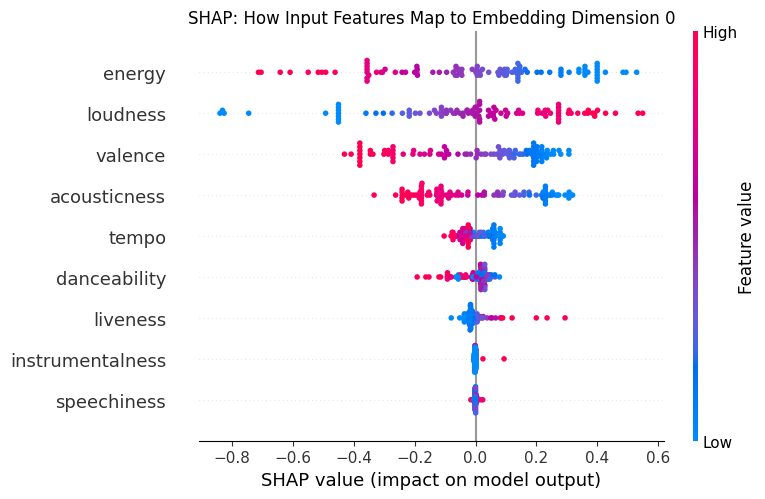

In [10]:
import shap
import matplotlib.pyplot as plt

# Explain what each embedding dimension captures
def embed_for_shap(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, z = model(x_tensor)
    return z.cpu().numpy()

# Take subset for speed
X_sample = X_scaled[:1000]
explainer = shap.KernelExplainer(embed_for_shap, X_sample[:100])

# Explain how input features map to embedding dim 0
shap_values = explainer.shap_values(X_sample[:100])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 0], X_sample[:100],
                  feature_names=AUDIO_FEATURES, show=False)
plt.title("SHAP: How Input Features Map to Embedding Dimension 0")
plt.tight_layout()
plt.show()

In [11]:
# 10: Evaluate reconstruction quality

model.eval()
with torch.no_grad():
    data_tensor = torch.from_numpy(X).to(device)
    x_hat, z = model(data_tensor)
    x_hat_np = x_hat.cpu().numpy()

mae = mean_absolute_error(X, x_hat_np)
print("Global MAE (on scaled features):", mae)

# Per-feature MAE
per_feature_mae = np.mean(np.abs(X - x_hat_np), axis=0)
for feat, m in zip(AUDIO_FEATURES, per_feature_mae):
    print(f"MAE[{feat}]: {m:.6f}")

# Convert MAE to "percentage of range" per feature (approx, since scaled)
# Here we just express MAE relative to 1 std (since data is standardized)
perc_per_feature = per_feature_mae * 100  # 1 std ≈ 100%
print("\nApprox per-feature error as % of 1 std (since standardized):")
for feat, p in zip(AUDIO_FEATURES, perc_per_feature):
    print(f"{feat}: {p:.2f}%")

mean_perc = np.mean(perc_per_feature)
print("\nMean approximate error across features:", f"{mean_perc:.2f}%")


Global MAE (on scaled features): 0.038262829184532166
MAE[danceability]: 0.033070
MAE[energy]: 0.040305
MAE[valence]: 0.046939
MAE[acousticness]: 0.037063
MAE[instrumentalness]: 0.029615
MAE[speechiness]: 0.045052
MAE[loudness]: 0.040766
MAE[tempo]: 0.037902
MAE[liveness]: 0.033653

Approx per-feature error as % of 1 std (since standardized):
danceability: 3.31%
energy: 4.03%
valence: 4.69%
acousticness: 3.71%
instrumentalness: 2.96%
speechiness: 4.51%
loudness: 4.08%
tempo: 3.79%
liveness: 3.37%

Mean approximate error across features: 3.83%


Computing t-SNE for latent space visualization...


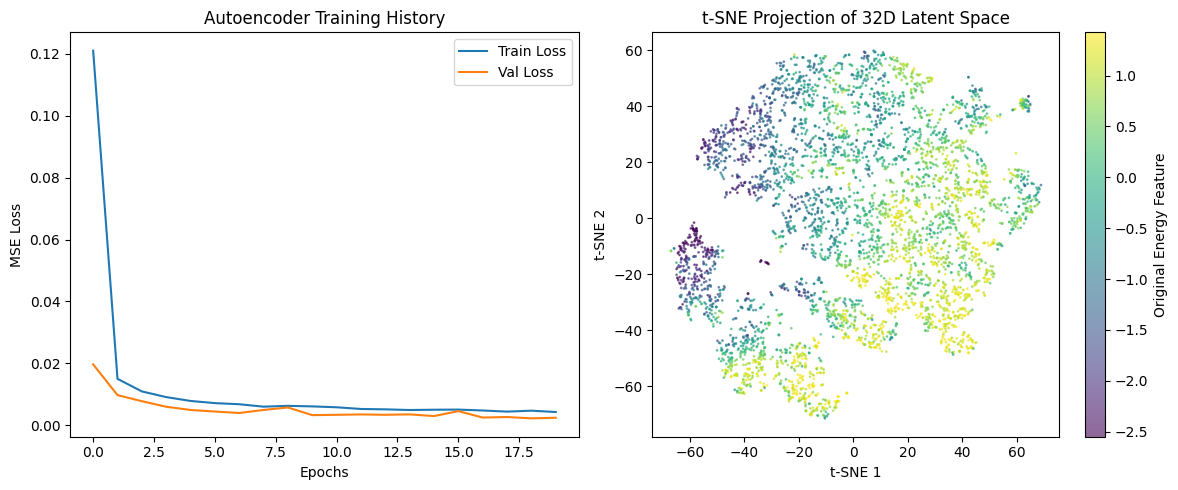

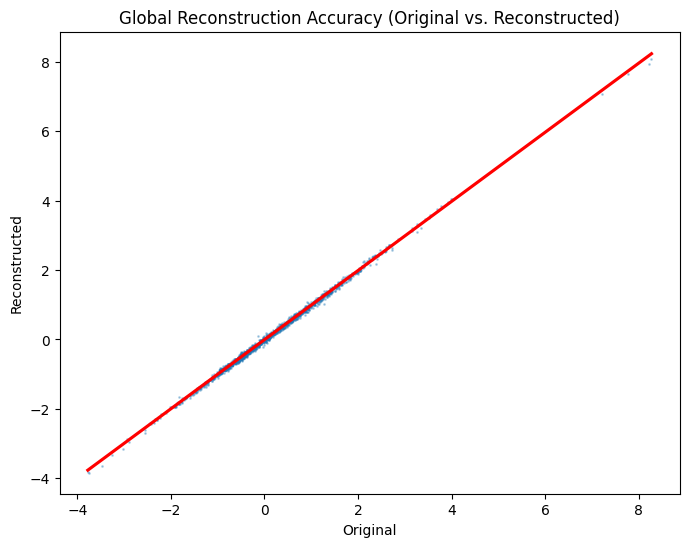

In [12]:
# 10.5: Visualizing Training History & Latent Space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Autoencoder Training History")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()

# 2. Latent Space Visualization using t-SNE
# We take a subset of 5,000 songs to make it faster
subset_size = 5000
indices = np.random.choice(len(embeddings), subset_size, replace=False)
z_subset = embeddings[indices]
features_subset = df.iloc[indices]

print("Computing t-SNE for latent space visualization...")
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z_subset)

plt.subplot(1, 2, 2)
# We color the points by 'Energy' to see if the latent space clustered them logically
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=features_subset['energy'],
                      cmap='viridis', alpha=0.6, s=1)
plt.colorbar(scatter, label='Original Energy Feature')
plt.title("t-SNE Projection of 32D Latent Space")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()
print("\n")

# 3. Reconstruction Correlation Heatmap
plt.figure(figsize=(8, 6))
reconstruction_corr = pd.DataFrame({
    "Original": X[indices].flatten(),
    "Reconstructed": x_hat_np[indices].flatten()
})
sns.regplot(data=reconstruction_corr.sample(2000), x="Original", y="Reconstructed",
            scatter_kws={'s':1, 'alpha':0.3}, line_kws={'color':'red'})
plt.title("Global Reconstruction Accuracy (Original vs. Reconstructed)")
plt.show()

In [13]:
# 11: Final summary info

# Define the model path if you haven't already
MODEL_PATH = PROCESSED_DIR / "autoencoder_model.pth"

print("===== FINAL AUTOENCODER SUMMARY =====")
print(f"Samples Processed:        {n_samples}")
print(f"Input Audio Features:     {n_features} ({', '.join(AUDIO_FEATURES)})")
print(f"Latent Dimensions:        {latent_dim}")
print(f"Final Validation MSE:     {best_val_loss:.6f}")
print(f"Global MAE (Scaled):      {mae:.6f}")
print(f"Mean Approx Error %:      {mean_perc:.2f}%")
print("-" * 37)
print(f"Scaler saved to:       {SONG_SCALER_FILE.name}")
print(f"Embeddings saved to:   {SONG_EMBEDDINGS_FILE.name}")
print(f"Weights saved to:      {MODEL_PATH.name}")
print("=====================================")

===== FINAL AUTOENCODER SUMMARY =====
Samples Processed:        114000
Input Audio Features:     9 (danceability, energy, valence, acousticness, instrumentalness, speechiness, loudness, tempo, liveness)
Latent Dimensions:        32
Final Validation MSE:     0.002271
Global MAE (Scaled):      0.038263
Mean Approx Error %:      3.83%
-------------------------------------
Scaler saved to:       song_scaler.pkl
Embeddings saved to:   song_embeddings.npy
Weights saved to:      autoencoder_model.pth
